# === STEP 0: Import Libraries ===

In [446]:
# --- Data Processing and Manipulation ---
import pandas as pd
import numpy as np

# --- Data Preprocessing ---
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# --- Train/Test Splitting ---
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

# --- Machine Learning Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Dimensionality Reduction and Clustering ---
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --- Evaluation Metrics ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# --- Visualization ---
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.cm import get_cmap

# --- Clustering Visualizations ---
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# === STEP 1: Load data ===

In [447]:
df = pd.read_csv('Final1_EDA_NewColumns.csv')
df

,Student ID,Academic Year,Gender,GPAX or Academic Performance,Class hours per week (total courses),Total courses registered,Participation Hours per week,Extracurricular and self-study hours per week,Feeling about studies,Sleep Hours per Day,...,Relationship Problems (past 30 days),Financial Stress (past 30 days),Feeling of Having Someone to Rely on (past 30 days),Balance Between Work/Study and Personal Life (past 30 days),Trouble Sleeping (too little or too much),Difficulty Concentrating,Irritable or Restless,Feeling Bored or Uninterested,Avoiding Social Interactions,SummaryST-5
0,66070501042,2,0,2.0,18,6.0,41.0,31.0,3.0,3.0,...,6,1,4,7,2,1,1,3,3,10
1,67070501005,1,0,1.0,18,6.0,4.0,0.0,0.0,5.0,...,3,3,1,4,1,1,0,1,0,3
2,66070501034,2,1,1.0,21,6.0,3.0,4.0,2.0,5.0,...,2,4,10,4,3,2,3,2,2,12
3,66070501082,2,1,3.0,6,3.0,2.0,8.0,3.0,8.0,...,2,10,7,7,2,2,2,3,3,12
4,66070501005,2,1,3.0,21,6.0,7.0,7.0,2.0,8.0,...,10,10,3,3,3,3,3,3,3,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,66070503450,2,0,1.0,22,6.0,2.0,7.0,2.0,5.0,...,3,2,7,4,0,1,2,0,2,5
98,66070501068,2,1,1.0,21,7.0,2.0,4.0,2.0,8.0,...,6,3,3,3,3,3,2,3,3,14
99,66070501031,2,1,2.0,21,6.0,0.0,0.0,2.0,8.0,...,3,5,4,6,0,1,1,1,2,5
100,66070503407,2,0,1.0,22,6.0,0.0,6.0,2.0,5.0,...,2,6,8,2,3,3,3,1,3,13


In [448]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 28 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Student ID                                                   102 non-null    int64  
 1   Academic Year                                                102 non-null    int64  
 2   Gender                                                       102 non-null    int64  
 3   GPAX or Academic Performance                                 102 non-null    float64
 4   Class hours per week (total courses)                         102 non-null    int64  
 5   Total courses registered                                     102 non-null    float64
 6   Participation Hours per week                                 102 non-null    float64
 7   Extracurricular and self-study hours per week                102 non-null    flo

In [449]:
summary_stats = pd.read_csv('summary_statistics.csv')
summary_stats

,Unnamed: 0,Student ID,Academic Year,Gender,GPAX or Academic Performance,Class hours per week (total courses),Total courses registered,Participation Hours per week,Extracurricular and self-study hours per week,Feeling about studies,...,Relationship Problems (past 30 days),Financial Stress (past 30 days),Feeling of Having Someone to Rely on (past 30 days),Balance Between Work/Study and Personal Life (past 30 days),Trouble Sleeping (too little or too much),Difficulty Concentrating,Irritable or Restless,Feeling Bored or Uninterested,Avoiding Social Interactions,SummaryST-5
0,count,1.020000e+02,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,...,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
1,mean,6.595266e+10,2.117647,0.490196,2.156863,18.980392,6.127451,5.852941,4.911765,1.588235,...,3.401961,4.235294,6.617647,5.215686,1.372549,1.627451,1.323529,1.872549,1.313725,7.509804
2,std,7.621172e+08,0.761631,0.521709,0.930720,5.056082,1.545812,10.014244,5.559940,0.882761,...,2.409798,2.692772,2.568060,1.958113,0.932595,0.831575,0.810351,0.908394,0.964523,3.013978
3,min,6.405070e+10,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,6.607050e+10,2.000000,0.000000,1.000000,18.000000,6.000000,0.000000,1.000000,1.000000,...,1.000000,2.000000,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000
5,50%,6.607050e+10,2.000000,0.000000,2.000000,21.000000,6.000000,2.000000,4.000000,2.000000,...,3.000000,4.000000,7.000000,5.000000,1.000000,2.000000,1.000000,2.000000,1.000000,8.000000
6,75%,6.607050e+10,2.000000,1.000000,3.000000,22.000000,6.000000,5.750000,7.000000,2.000000,...,5.000000,6.000000,8.000000,7.000000,2.000000,2.000000,2.000000,3.000000,2.000000,10.000000
7,max,6.707051e+10,4.000000,2.000000,5.000000,27.000000,13.000000,41.000000,31.000000,3.000000,...,10.000000,10.000000,10.000000,10.000000,3.000000,3.000000,3.000000,3.000000,3.000000,15.000000


In [450]:
summary_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 29 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Unnamed: 0                                                   8 non-null      object 
 1   Student ID                                                   8 non-null      float64
 2   Academic Year                                                8 non-null      float64
 3   Gender                                                       8 non-null      float64
 4   GPAX or Academic Performance                                 8 non-null      float64
 5   Class hours per week (total courses)                         8 non-null      float64
 6   Total courses registered                                     8 non-null      float64
 7   Participation Hours per week                                 8 non-null      float64

# === STEP 2: Target Variable ===

In [451]:
# สร้างคอลัมน์ Stress_Level จากคะแนน ST-5
def classify_stress_level(score):
    if 0 <= score <= 4:
        return 'Low Stressed'
    elif 5 <= score <= 7:
        return 'Medium Stressed'
    elif 8 <= score <= 9:
        return 'High Stressed'
    elif 10 <= score <= 15:
        return 'Very High Stressed'
    else:
        return np.nan

df['Stress_Level'] = df['SummaryST-5'].apply(classify_stress_level)

In [452]:
# Print the original stress levels
print("Original Stress Levels:")
print(df['Stress_Level'].unique())

# Print the mapping of original labels to encoded values
print("\nEncoded Stress Levels:")
encoded_labels = {
    "Low Stressed": 0,
    "Medium Stressed": 1,
    "High Stressed": 2,
    "Very High Stressed": 3
}

for label, encoded_value in encoded_labels.items():
    print(f"{label}: {encoded_value}")

Original Stress Levels:
['Very High Stressed' 'Low Stressed' 'Medium Stressed' 'High Stressed']

Encoded Stress Levels:
Low Stressed: 0
Medium Stressed: 1
High Stressed: 2
Very High Stressed: 3


# === STEP 3: columns to drop ===

In [453]:
# Identify the columns to drop
columns_to_drop = [
    "Trouble Sleeping (too little or too much)",
    "Difficulty Concentrating",
    "Irritable or Restless",
    "Feeling Bored or Uninterested",
    "Avoiding Social Interactions",
    'SummaryST-5',
    'Stress_Level',
    'Difficulty focusing thoughts',
    'Mood Swings Frequency',
    'Stress Level (past 30 days)',
    'Anxiety or Depressive Symptoms (past 30 days)',
    'Student ID'
]

# Drop rows with invalid or missing categories
df = df.dropna(subset=['Stress_Level'])

# Prepare features and target
X = df.drop(columns=columns_to_drop)
y = df['Stress_Level']

# === STEP 4: SMOTE ===

In [454]:
# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [455]:
# Feature scaling (optional but recommended)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [456]:
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

# === STEP 5: Optuna ===

In [457]:
# Define the Optuna objective function
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),  # Corrected choices
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])  # Corrected choices
    }

    model = RandomForestClassifier(**params, random_state=42)

    # Use cross-validation to evaluate model performance
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring='f1_weighted', n_jobs=-1)
    return scores.mean()

In [458]:
# Perform hyperparameter tuning with Optuna
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, n_jobs=1)

print("Best hyperparameters:", study.best_params)
print("Best cross-validated F1 score:", study.best_value)

[I 2025-05-08 10:31:58,620] A new study created in memory with name: no-name-9942ea34-ee0a-4f5b-9a14-2a7a639796ef
[I 2025-05-08 10:32:01,664] Trial 0 finished with value: 0.5223664302849824 and parameters: {'n_estimators': 128, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'class_weight': None}. Best is trial 0 with value: 0.5223664302849824.
[I 2025-05-08 10:32:02,808] Trial 1 finished with value: 0.5093914379384465 and parameters: {'n_estimators': 206, 'max_depth': 22, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False, 'class_weight': None}. Best is trial 0 with value: 0.5223664302849824.
[I 2025-05-08 10:32:04,080] Trial 2 finished with value: 0.5388938413410511 and parameters: {'n_estimators': 209, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5388938413410511.
[I

Best hyperparameters: {'n_estimators': 127, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'class_weight': 'balanced_subsample'}
Best cross-validated F1 score: 0.6026569441954057


In [459]:
# Train the final model with the best parameters
best_params = study.best_params
final_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    bootstrap=best_params['bootstrap'],
    class_weight=best_params['class_weight'],
    random_state=42
)

# === STEP 6: Train/Test Split ===

In [460]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
    )

final_model.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False, class_weight='balanced_subsample',
                       max_depth=30, min_samples_split=4, n_estimators=127,
                       random_state=42)

In [461]:
# Make predictions on the test set
y_pred = final_model.predict(X_test)

# === STEP 7: Evaluate the model ===

In [462]:
# Evaluate the model
print("\nTest Set Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Set Evaluation:
Accuracy: 0.5925925925925926
Precision: 0.6141975308641976
Recall: 0.5925925925925926
F1 Score: 0.5858585858585859

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.56      0.83      0.67         6
           2       0.57      0.57      0.57         7
           3       0.57      0.57      0.57         7

    accuracy                           0.59        27
   macro avg       0.61      0.60      0.59        27
weighted avg       0.61      0.59      0.59        27



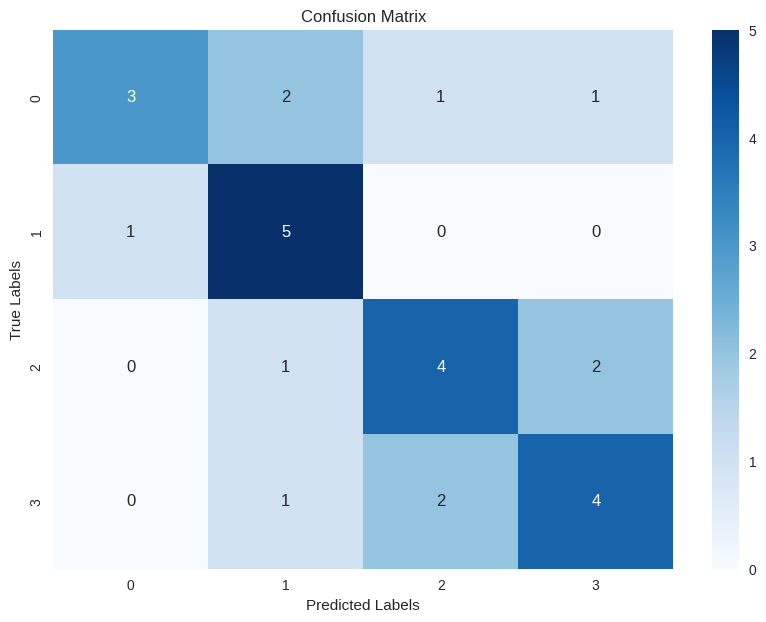

In [463]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

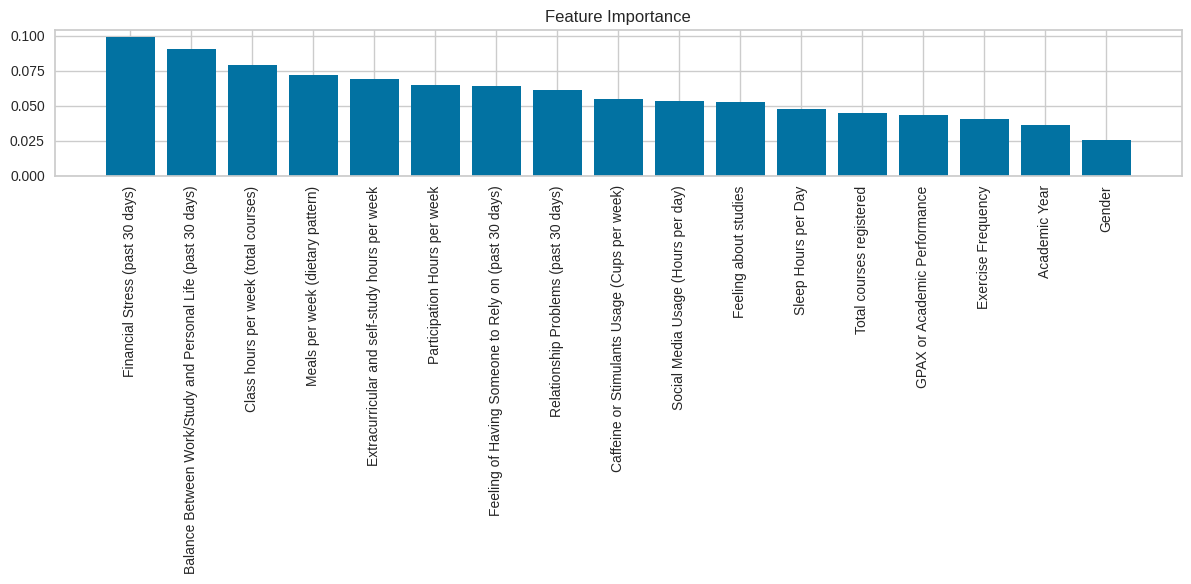

In [466]:
# Feature Importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title('Feature Importance')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()